# Intro

Name:  

    Hyperion_plots

Purpose:  

    Make some plot for the hyperion isofit reprocessing to view the 'before and after'

Input:

    none at command line

Output:

    plots

Keywords:

    none

Dependencies:

    - numpy
    - Pyephem
    - pandas

Needed Files:

  - hyperion L0, L1r, L2 files

Modification History:

    Written: Samuel LeBlanc, Santa Cruz, 2026-03-23
    Modified: 

# Load the required modules

In [1]:
import matplotlib 
import matplotlib.pyplot as plt
import numpy as np
import os
import netCDF4 as nc
from datetime import datetime
import matplotlib.patches as patches
import matplotlib.patheffects as pe
import spectral
import spectral.io.envi as envi

In [ ]:
from hyperion_isofitv3 import test, hyperion, hyperion2isofit

In [30]:
if __name__ == "__main__":
    import map_utils as mu
    import matplotlib.colors as colors
    from path_utils import getpath

In [4]:
if __name__ == "__main__":
    fp = getpath('Hyperion')#,path=r"/data2/SBG/Hyperion_data",make_path=True)
    fp

Return path named:  Hyperion /data2/SBG/Hyperion_data/


'/data2/SBG/Hyperion_data/'

# Define some basic functions

In [154]:
def norm_rgb(rgb_raw,rgb_max=None):
    rgb_min = np.nanmin(rgb_raw)
    if rgb_max is None:
        rgb_max = np.nanmax(rgb_raw)
    return (rgb_raw - rgb_min) / (rgb_max - rgb_min)

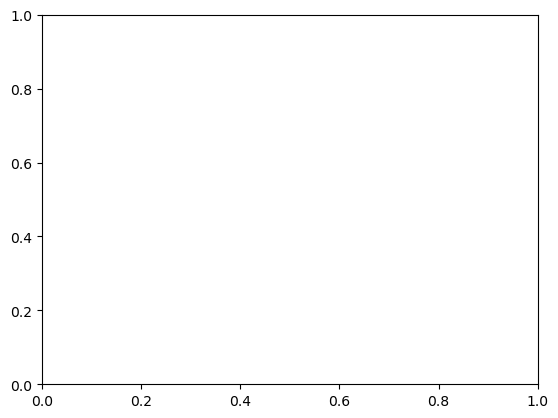

In [75]:
def plot_lon_lats(lons,lats,ax=plt.gca(),color='orange'):
    'quick plot of the latitudde and longitude lines'
    lon_lines = ax.contour(lons, levels=10, colors=color, linewidths=0.5, alpha=0.7)
    lat_lines = ax.contour(lats, levels=10, colors=color, linewidths=0.5, alpha=0.7)
    ax.clabel(lon_lines, inline=True, fontsize=11, 
              fmt=lambda x: f"{abs(x):.2f}{'E' if x >= 0 else 'W'}")
    ax.clabel(lat_lines, inline=True, fontsize=11, 
              fmt=lambda x: f"{abs(x):.2f}{'N' if x >= 0 else 'S'}")

In [189]:
def select_pixels(rgb_array,verbose=False):
    #optimize to only select in steps of 10
    step = 10
    if type(rgb_array) is type(np.array([0])):
        subsampled = rgb_array[::step, ::step, :]
    else:
        subsampled = rgb_array.isel(**{'Along Track': slice(0, None, step), 'Cross Track': slice(0, None, step)}).values
    h_sub, w_sub, _ = subsampled.shape
    
    # 1. Flatten the image to a list of pixels: (9000*250, 3)
    pixels = subsampled.reshape(-1, 3)
    
    # 2. Calculate Intensity (Brightness) for each pixel
    # Simple average of R, G, B channels
    intensity = np.mean(pixels, axis=1)
    
    # --- 5th and 95th Percentile Brightness ---
    dim_val = np.percentile(intensity, 5)
    bright_val = np.percentile(intensity, 95)
    
    # Find the index of the pixel closest to these values
    idx_dim = np.abs(intensity - dim_val).argmin()
    idx_bright = np.abs(intensity - bright_val).argmin()
    
    # --- The "Greenest" Pixel ---
    # Defined as max(Green - Red) + (Green - Blue)
    greeness = (pixels[:, 1] - pixels[:, 0]) + (pixels[:, 1] - pixels[:, 2])
    idx_green = np.argmax(greeness)
    
    # --- 2 Random Pixels ---
    idx_random = np.random.choice(len(pixels), 2, replace=False)
    
    # 3. Consolidate Indices
    #target_indices = [idx_dim, idx_bright, idx_green, idx_random[0], idx_random[1]]
    target_sub_indices = [idx_dim, idx_bright, idx_green, idx_random[0], idx_random[1]]
    
    # 4. Map back to (y, x) coordinates
    coords = []#[(idx // 250, idx % 250) for idx in target_indices]
    for idx in target_sub_indices:
        y_sub = idx // w_sub
        x_sub = idx % w_sub
        coords.append((y_sub * step, x_sub * step)) # Scale back up
    
    labels = ["5th % Dimmest", "95th % Brightest", "Greenest", "Random 1", "Random 2"]
    if verbose:
        for label, (y, x) in zip(labels, coords):
            print(f"{label}: Pixel at y={y}, x={x}")
    return coords,labels


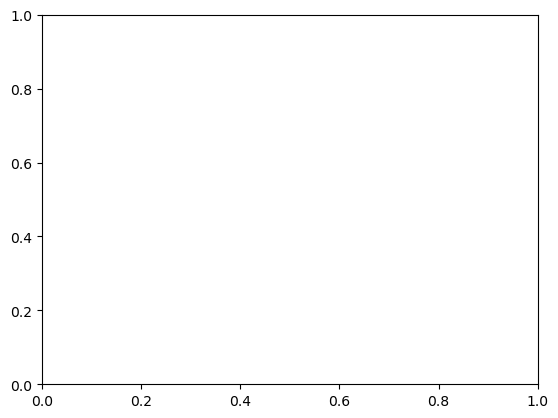

In [213]:
def plot_squares_on_select(coords,colors=['red', 'blue', 'green', 'teal', 'yellow'],square_size=20,ax=plt.gca(),labels=[]):
    'Plotting some squares on the image for the selected pixels'

    for i, (y, x) in enumerate(coords):
        # Rectangle( (x_start, y_start), width, height )
        # We subtract half the size to center the square on the pixel
        rect = patches.Rectangle(
            (x - square_size//2, y - square_size//2), 
            square_size, square_size*4, 
            linewidth=1, 
            edgecolor=colors[i], 
            facecolor='none'
        )
        
        rect.set_path_effects([pe.withStroke(linewidth=2, foreground='black')])
        
        # Add to plot
        ax.add_patch(rect)
    
        # Optional: Add a small label above each square
        if any(labels):
            ax.text(x, y - square_size, labels[i], color=colors[i], 
                    fontsize=9, ha='center')
            

# Define a class for combining all these plotting utils

In [264]:
class make_hyperion_plots():   
    def __init__(self,scene):
        self.paths = hyperion2isofit.readHyperionL2(scene)
        self.i_rgb = (22,11,5) 
        self.scene = scene

    def prep_reflectance_calcs(self):
        obs = spectral.open_image(self.paths['obs'])
        self.sza = obs[:,:,4]

        self.paths['lut_full'] = os.path.join(self.paths['L1dir'],'lut_full','lut.nc')
        lut_fp = nc.Dataset(self.paths['lut_full'],'r')
        self.solar_irr = lut_fp['solar_irr'][:]

    def rad2rfl(self,rad):
        return np.pi*rad/self.solar_irr*np.cos(self.sza*np.pi/180.0)

    def plot_in_out_reflectance(self):
        img = spectral.open_image(self.paths['rfl'])
        img_in = spectral.open_image(self.paths['radiance'])
        
        layout = [['I','O',  'S0'], ['I','O',  'S1'],['I','O',  'S2'],['I','O',  'S3'],['I','O',  'S4']]
        fig, axd = plt.subplot_mosaic(layout, figsize=(9, 6), 
                                      gridspec_kw={'width_ratios': [1, 1, 4]})
        
        axd['O'].set_title('Reflectance output')
        axd['I'].set_title('Reflectance input')
        
        # convert radiance to reflectance
        rfl_in = self.rad2rfl(img_in.load())
        
        view = axd['I'].imshow(norm_rgb(rfl_in[:,:,i_rgb],rgb_max=1.0),aspect=0.2)#,ax=axd['I']
        viewo = axd['O'].imshow(norm_rgb(img.read_bands(i_rgb),rgb_max=1.0),aspect=0.2)#,ax=axd['I'])
        axd['I'].set_xlim(1,img.shape[1])
        axd['O'].set_xlim(1,img.shape[1])
        
        plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['I'])
        plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['O'])
        
        try:
            add_coast(paths['lonlat'][0],paths['lonlat'][1],ax=axd['I'],xlen=img.shape[1],ylen=img.shape[0])
        except:
            print('** Error adding coast, ignoring **')
        
        coords,labels = select_pixels(img.read_bands(i_rgb))
        colors = ['red', 'blue', 'green', 'teal', 'yellow']
        
        plot_squares_on_select(coords,labels=labels,ax=axd['I'],colors=colors)
        plot_squares_on_select(coords,labels=labels,ax=axd['O'],colors=colors)
        
        #now plot the spectra
        wavelengths = self.paths['w']*1000.0
        self.wl = wavelengths
        for i, (name, (y, x)) in enumerate(zip(labels, coords)):
            ax_s = axd[f'S{i}']
            
            spectrum_o = img.read_pixel(y,x)
            spectrum_i = self.rad2rfl(img_in.read_pixel(y,x))[y,x]
            
            ax_s.plot(wavelengths, spectrum_i, color=colors[i], linewidth=2,alpha=0.5,label='input')
            ax_s.plot(wavelengths, spectrum_o, color=colors[i], linewidth=2,label='output')
            ax_s.legend(frameon=False,prop={'size': 7}, labelspacing=0.1, handletextpad=0.3, handlelength=1.0)
            
            ax_s.set_title(f"Spectrum: {name}", color=colors[i], fontsize=10, loc='left')
            ax_s.set_ylim(-0.2,1.2)
            ax_s.grid(True, alpha=0.2)
            axd[f'S{i}'].sharex(axd['S0'])
            if i < 4:
                ax_s.tick_params(labelbottom=False)
            else:
                ax_s.set_xlabel("Wavelength [nm]")
                ax_s.tick_params(labelbottom=True)
                ax_s.set_xticks([500,750,1000,1250,1500,1750,2000,2250])
        
        fig.tight_layout()
        plt.subplots_adjust(top=0.92) 
        start = datetime.strptime(self.paths['attrs']['Scene_Star'][:17],'%Y:%j:%H:%M:%S')
        stop = datetime.strptime(self.paths['attrs']['Scene_Stop'][:17],'%Y:%j:%H:%M:%S')
        mlon,mlat = np.nanmean(self.paths['lonlat'][0]),np.nanmean(self.paths['lonlat'][1])
        lon_fmt = lambda x: f"{abs(x):.2f}{'E' if x >= 0 else 'W'}"
        lat_fmt = lambda x: f"{abs(x):.2f}{'N' if x >= 0 else 'S'}"

        fig.suptitle(f'{self.scene} - {start:%Y/%m/%d - %H:%M:%S} to {stop:%H:%M:%S} at {lon_fmt(mlon)},{lat_fmt(mlat)}')
        return fig
                

# Main processing scripts

In [273]:
def make_error_figure(e,scene=''):
    'make a simple figure with just the error'
    error_fig, ax_err = plt.subplots(figsize=(4, 2))
    ax_err.axis('off') # Hide the plot box/axes
    
    # Format the error message text
    error_text = f"Error making the figure for scene: {scene}\n\nError Detail:\n{str(e)}"
    
    ax_err.text(0.5, 0.5, error_text, 
                color='red', fontweight='bold', ha='center', va='center',
                wrap=True, fontsize=12, family='monospace')
    return error_fig

In [295]:
def make_figs_for_one_scene(scene,path=''):
    'Main run for building the figures for one scene'
    try:
        hyp_plot = make_hyperion_plots(scene)
        hyp_plot.prep_reflectance_calcs()
        fig = hyp_plot.plot_in_out_reflectance()
        fig_name = scene+'_Reflectance.png'
        if not path:
            path = hyp_plot.paths['L1Rdir']
        rts = 0
    except Exception as e:
        print(f"***Error: {scene} - figure was not made. {str(e)}")
        fig = make_error_figure(e,scene)
        fig_name = scene+'_Reflectance_ERROR.png'
        if not path:
            path = '.'
        rts = -1
    try:
        fig.savefig(os.path.join(path,fig_name),dpi=600,transparent=True)
    except Exception as e:
        print(f"***Error: {scene} - Saving difficulty: {str(e)}")
        rts = -2
    try:
        plt.close(fig)
    except:
        pass
    return rts        

In [297]:
def main_figs_looper(in_paths='.'):
    'looping over the paths to select the scenes to plot'
    scenes = [l for l in ls if os.path.isdir(os.path.join(in_paths,l)) and l.startswith('EO1')]
    n = len(scenes)
    for i,scene in enumerate(scenes):
        print(f' {i} of {n}: on scene {scene}')
        try:
            rts = make_figs_for_one_scene(scene,path=in_paths)
        except Exception as e:
            print(f'*** ERROR with scene: {scene}, error: {str(e)} ***' )
        
    print('!Done!')

In [298]:
if __name__ == "__main__":
    main_figs_looper(in_paths=fp)

 0 of 8: on scene EO1H0400332013093110K7_bak
***Error: EO1H0400332013093110K7_bak - figure was not made. list index out of range
 1 of 8: on scene EO1H0400332016183110K7
Attributes not found for Scene ID EO1H0400332016183110K7.
***Error: EO1H0400332016183110K7 - figure was not made. 'int' object does not support item assignment
 2 of 8: on scene EO1H0400332013312110P1
/data2/SBG/Hyperion_data/EO1H0400332013312110P1/EO1H0400332013312110P1.L1R
** Error adding coast, ignoring **
 3 of 8: on scene EO1H0400332013093110K7_incomplte
***Error: EO1H0400332013093110K7_incomplte - figure was not made. list index out of range
 4 of 8: on scene EO1H0440142015120110K4
Attributes not found for Scene ID EO1H0440142015120110K4.
***Error: EO1H0440142015120110K4 - figure was not made. 'int' object does not support item assignment
 5 of 8: on scene EO1H0890822006354110PX
/data2/SBG/Hyperion_data/EO1H0890822006354110PX/EO1H0890822006354110PX.L1R


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1435988].


 6 of 8: on scene EO1H0400332013093110K7
***Error: EO1H0400332013093110K7 - figure was not made. list index out of range
 7 of 8: on scene EO1H0440342016184110KF
/data2/SBG/Hyperion_data/EO1H0440342016184110KF/EO1H0440342016184110KF.L1R
***Error: EO1H0440342016184110KF - figure was not made. Unable to locate file "/data2/SBG/Hyperion_data/EO1H0440342016184110KF/EO1H0440342016184110KFobs.hdr". If the file exists, use its full path or place its directory in the SPECTRAL_DATA environment variable.
!Done!


# Select and load a scene

## Sam style

In [15]:
if __name__ == "__main__":
    i_rgb = (22,11,5) #near rgb
    #i_rgb = (150,11,5) # not real

 Load the radiance L2 values and plot em

/home/sam/mambaforge/envs/isofit_env/lib/python3.12/site-packages/spectral/graphics/spypylab.py:796: UserWarning: Failed to create RectangleSelector object. Interactive pixel class labeling will be unavailable.
  warnings.warn(msg)


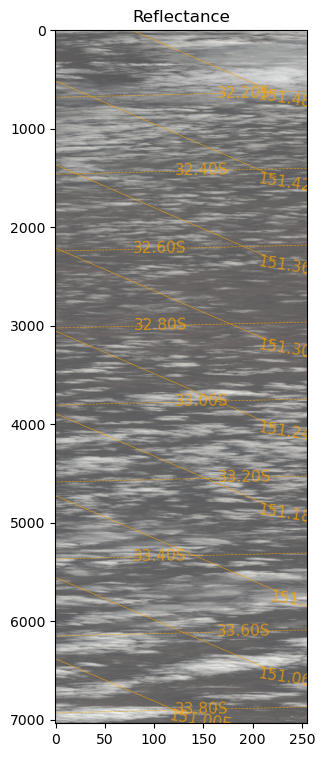

In [16]:
if __name__ == "__main__":
    img = spectral.open_image(paths['radiance'])
    view = spectral.imshow(img, bands=i_rgb,figsize=(9,9),aspect=0.1)
    ax = plt.gca() # Get current axes
    
    # 2. Extract Lon and Lat arrays
    lons = paths['lonlat'][0]
    lats = paths['lonlat'][1]
    
    # 3. Overlay the grid lines using contour
    # 'levels' defines how many grid lines you want
    lon_lines = ax.contour(lons, levels=10, colors='orange', linewidths=0.5, alpha=0.7)
    lat_lines = ax.contour(lats, levels=10, colors='orange', linewidths=0.5, alpha=0.7)
    
    # 4. Optional: Add labels to the grid lines
    ax.clabel(lon_lines, inline=True, fontsize=11, 
              fmt=lambda x: f"{abs(x):.2f}{'E' if x >= 0 else 'W'}")
    
    # Latitude: Positive = N, Negative = S
    ax.clabel(lat_lines, inline=True, fontsize=11, 
              fmt=lambda x: f"{abs(x):.2f}{'N' if x >= 0 else 'S'}")
    plt.title('Reflectance')
    plt.show()

Load the L1R and plot it

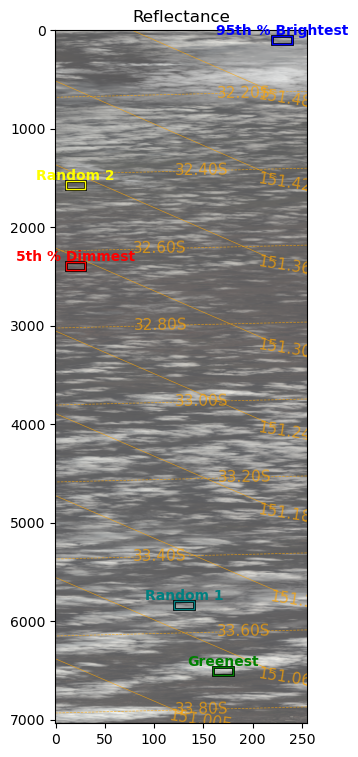

In [65]:
if __name__ == "__main__":
    view = spectral.imshow(image_L1r.values,figsize=(9,9),aspect=0.1)
    ax = plt.gca() # Get current axes
    
    # 2. Extract Lon and Lat arrays
    lons = paths['lonlat'][0]
    lats = paths['lonlat'][1]
    
    # 3. Overlay the grid lines using contour
    # 'levels' defines how many grid lines you want
    lon_lines = ax.contour(lons, levels=10, colors='orange', linewidths=0.5, alpha=0.7)
    lat_lines = ax.contour(lats, levels=10, colors='orange', linewidths=0.5, alpha=0.7)
    
    # 4. Optional: Add labels to the grid lines
    ax.clabel(lon_lines, inline=True, fontsize=11, 
              fmt=lambda x: f"{abs(x):.2f}{'E' if x >= 0 else 'W'}")
    
    # Latitude: Positive = N, Negative = S
    ax.clabel(lat_lines, inline=True, fontsize=11, 
              fmt=lambda x: f"{abs(x):.2f}{'N' if x >= 0 else 'S'}")
    plt.title('Reflectance')
    
    coords,labels = select_pixels(image_L1r)
    plot_squares_on_select(coords,labels=labels,ax=ax)
    
    plt.show()


5th % Dimmest: Pixel at y=2360, x=20
95th % Brightest: Pixel at y=70, x=230
Greenest: Pixel at y=6470, x=170
Random 1: Pixel at y=2740, x=130
Random 2: Pixel at y=4780, x=110


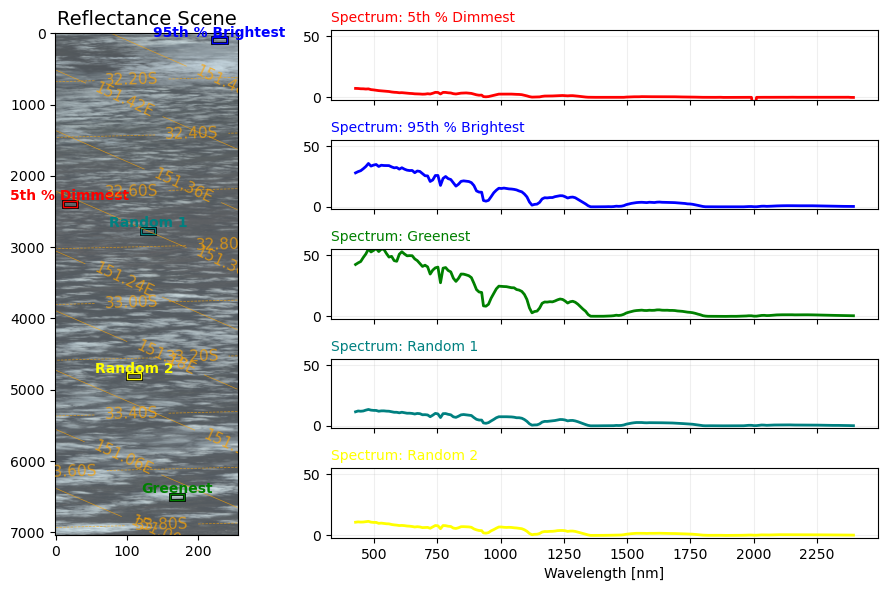

In [82]:
if __name__ == "__main__":
    layout = [['I', 'S0'], ['I', 'S1'],['I', 'S2'],['I', 'S3'],['I', 'S4']]
    fig, axd = plt.subplot_mosaic(layout, figsize=(9, 6), 
                                  gridspec_kw={'width_ratios': [1, 3]})
    
    # plot the main figure
    
    view = axd['I'].imshow(norm_rgb(image_L1r.values), aspect=0.1)#, ax=axd['I'])
    axd['I'].set_title('L1R Reflectance Scene', fontsize=14)
    
    plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['I'])
    
    coords,labels = select_pixels(image_L1r)
    colors = ['red', 'blue', 'green', 'teal', 'yellow']
    
    plot_squares_on_select(coords,labels=labels,ax=axd['I'],colors=colors)
    
    #now plot the spectra
    wavelengths = wl.values
    for i, (name, (y, x)) in enumerate(zip(labels, coords)):
        # Select the specific subplot for this pixel (S0, S1, etc.)
        ax_s = axd[f'S{i}']
        spectrum = image.isel(**{'Along Track': y, 'Cross Track': x}).values
        ax_s.plot(wavelengths, spectrum, color=colors[i], linewidth=2)
        
        ax_s.set_title(f"Spectrum: {name}", color=colors[i], fontsize=10, loc='left')
        ax_s.set_ylim(-2,55)
        ax_s.grid(True, alpha=0.2)
        axd[f'S{i}'].sharex(axd['S0'])
        if i < 4:
            #ax_s.set_xticklabels([''])
            ax_s.tick_params(labelbottom=False)
        else:
            ax_s.set_xlabel("Wavelength [nm]")
            ax_s.tick_params(labelbottom=True)
            ax_s.set_xticks([500,750,1000,1250,1500,1750,2000,2250])
    
    plt.tight_layout()
    plt.show()


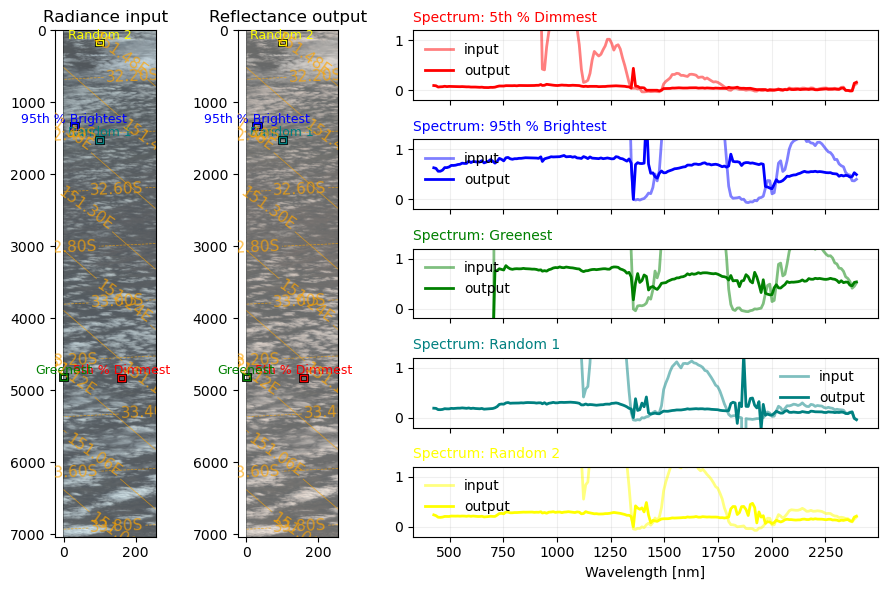

In [214]:
if __name__ == "__main__":
    img = spectral.open_image(paths['rfl'])
    img_in = spectral.open_image(paths['radiance'])
    layout = [['I','O',  'S0'], ['I','O',  'S1'],['I','O',  'S2'],['I','O',  'S3'],['I','O',  'S4']]
    fig, axd = plt.subplot_mosaic(layout, figsize=(9, 6), 
                                  gridspec_kw={'width_ratios': [1, 1, 4]})
    
    axd['O'].set_title('Reflectance output')
    axd['I'].set_title('Radiance input')
    
    #view = spectral.imshow(img, bands=i_rgb,aspect=0.1)
    view = axd['I'].imshow(norm_rgb(img_in.read_bands(i_rgb)),aspect=0.2)#,ax=axd['I']
    viewo = axd['O'].imshow(norm_rgb(img.read_bands(i_rgb)),aspect=0.2)#,ax=axd['I'])
    
    #ax = plt.gca() # Get current axes
    plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['I'])
    plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['O'])
    
    #plt.title('Reflectance output')
    
    colors = ['red', 'blue', 'green', 'teal', 'yellow']
    
    plot_squares_on_select(coords,labels=labels,ax=axd['I'],colors=colors)
    plot_squares_on_select(coords,labels=labels,ax=axd['O'],colors=colors)
    
    #now plot the spectra
    wavelengths = wl.values
    for i, (name, (y, x)) in enumerate(zip(labels, coords)):
        # Select the specific subplot for this pixel (S0, S1, etc.)
        ax_s = axd[f'S{i}']
       # spectrum = img.isel(**{'Along Track': y, 'Cross Track': x}).values
        spectrum_o = img.read_pixel(y,x)
        spectrum_i = img_in.read_pixel(y,x)
        
        ax_s.plot(wavelengths, spectrum_i, color=colors[i], linewidth=2,alpha=0.5,label='input')
        ax_s.plot(wavelengths, spectrum_o, color=colors[i], linewidth=2,label='output')
        ax_s.legend(frameon=False)
        
        ax_s.set_title(f"Spectrum: {name}", color=colors[i], fontsize=10, loc='left')
        ax_s.set_ylim(-0.2,1.2)
        ax_s.grid(True, alpha=0.2)
        axd[f'S{i}'].sharex(axd['S0'])
        if i < 4:
            #ax_s.set_xticklabels([''])
            ax_s.tick_params(labelbottom=False)
        else:
            ax_s.set_xlabel("Wavelength [nm]")
            ax_s.tick_params(labelbottom=True)
            ax_s.set_xticks([500,750,1000,1250,1500,1750,2000,2250])
    
    fig.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1435988].


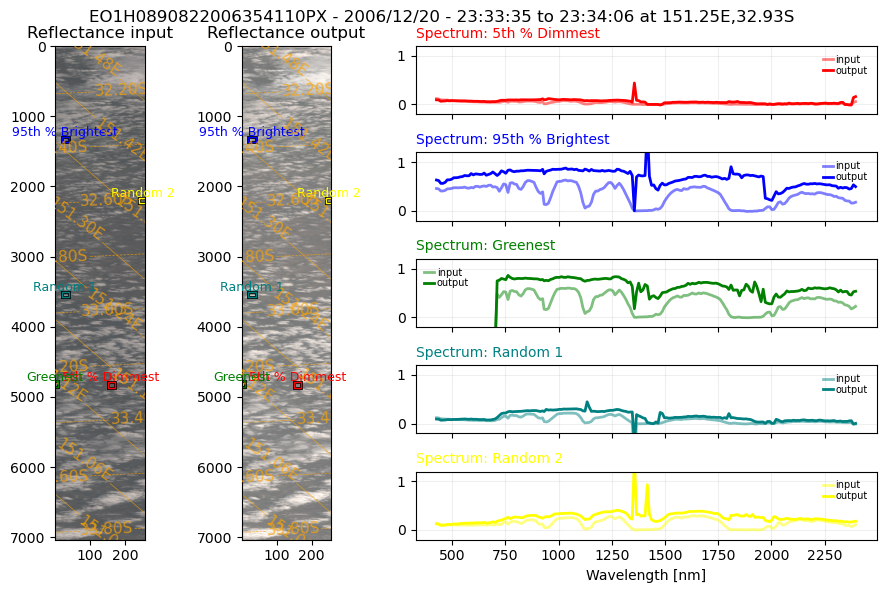

In [231]:
if __name__ == "__main__":
    img = spectral.open_image(paths['rfl'])
    img_in = spectral.open_image(paths['radiance'])
    layout = [['I','O',  'S0'], ['I','O',  'S1'],['I','O',  'S2'],['I','O',  'S3'],['I','O',  'S4']]
    fig, axd = plt.subplot_mosaic(layout, figsize=(9, 6), 
                                  gridspec_kw={'width_ratios': [1, 1, 4]})
    
    axd['O'].set_title('Reflectance output')
    axd['I'].set_title('Reflectance input')
    
    # convert radiance to reflectance
    rfl_in = rad2rfl(img_in.load())
    
    view = axd['I'].imshow(norm_rgb(rfl_in[:,:,i_rgb],rgb_max=1.0),aspect=0.2)#,ax=axd['I']
    viewo = axd['O'].imshow(norm_rgb(img.read_bands(i_rgb),rgb_max=1.0),aspect=0.2)#,ax=axd['I'])
    axd['I'].set_xlim(1,img.shape[1])
    axd['O'].set_xlim(1,img.shape[1])
    
    plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['I'])
    plot_lon_lats(paths['lonlat'][0],paths['lonlat'][1],ax=axd['O'])
    
    add_coast(paths['lonlat'][0],paths['lonlat'][1],ax=axd['I'],xlen=img.shape[1],ylen=img.shape[0])
    
    coords,labels = select_pixels(img.read_bands(i_rgb))
    colors = ['red', 'blue', 'green', 'teal', 'yellow']
    
    plot_squares_on_select(coords,labels=labels,ax=axd['I'],colors=colors)
    plot_squares_on_select(coords,labels=labels,ax=axd['O'],colors=colors)
    
    #now plot the spectra
    wavelengths = wl.values
    for i, (name, (y, x)) in enumerate(zip(labels, coords)):
        # Select the specific subplot for this pixel (S0, S1, etc.)
        ax_s = axd[f'S{i}']
       # spectrum = img.isel(**{'Along Track': y, 'Cross Track': x}).values
        spectrum_o = img.read_pixel(y,x)
        spectrum_i = rad2rfl(img_in.read_pixel(y,x))[y,x]
        
        ax_s.plot(wavelengths, spectrum_i, color=colors[i], linewidth=2,alpha=0.5,label='input')
        ax_s.plot(wavelengths, spectrum_o, color=colors[i], linewidth=2,label='output')
        ax_s.legend(frameon=False,prop={'size': 7}, labelspacing=0.1, handletextpad=0.3, handlelength=1.0)
        
        ax_s.set_title(f"Spectrum: {name}", color=colors[i], fontsize=10, loc='left')
        ax_s.set_ylim(-0.2,1.2)
        ax_s.grid(True, alpha=0.2)
        axd[f'S{i}'].sharex(axd['S0'])
        if i < 4:
            #ax_s.set_xticklabels([''])
            ax_s.tick_params(labelbottom=False)
        else:
            ax_s.set_xlabel("Wavelength [nm]")
            ax_s.tick_params(labelbottom=True)
            ax_s.set_xticks([500,750,1000,1250,1500,1750,2000,2250])
    
    fig.tight_layout()
    plt.subplots_adjust(top=0.92) 
    start = datetime.strptime(paths['attrs']['Scene_Star'][:17],'%Y:%j:%H:%M:%S')
    stop = datetime.strptime(paths['attrs']['Scene_Stop'][:17],'%Y:%j:%H:%M:%S')
    mlon,mlat = np.nanmean(paths['lonlat'][0]),np.nanmean(paths['lonlat'][1])
    lon_fmt = lambda x: f"{abs(x):.2f}{'E' if x >= 0 else 'W'}"
    lat_fmt = lambda x: f"{abs(x):.2f}{'N' if x >= 0 else 'S'}"
    fig.suptitle(f'{scene} - {start:%Y/%m/%d - %H:%M:%S} to {stop:%H:%M:%S} at {lon_fmt(mlon)},{lat_fmt(mlat)}')
    plt.show()

In [234]:
if __name__ == "__main__":
    fig.savefig(os.path.join(paths['L1dir'],scene+'_Reflectance.png'),dpi=600,transparent=True)

# Tester area

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1435988].


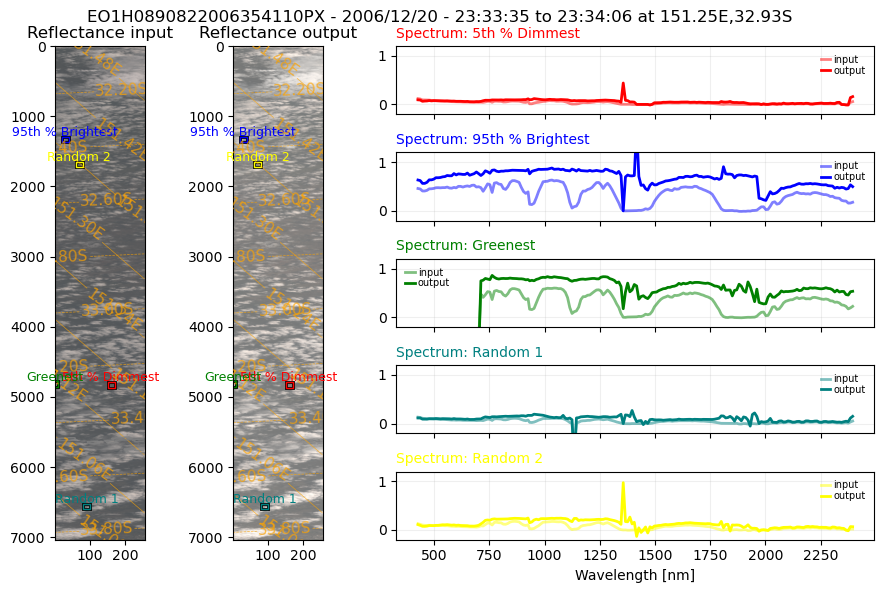

In [241]:
if __name__ == "__main__":
    hyp_plot = make_hyperion_plots(scene)
    hyp_plot.prep_reflectance_calcs()
    fig = hyp_plot.plot_in_out_reflectance()

/data2/SBG/Hyperion_data/EO1H0400332013312110P1/EO1H0400332013312110P1.L1R
** Error adding coast, ignoring **


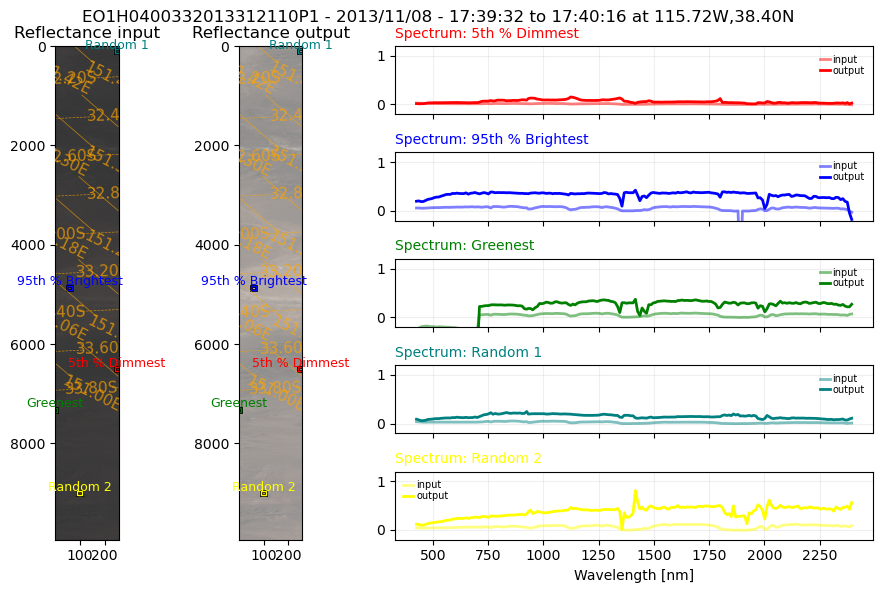

In [265]:
if __name__ == "__main__":
    scene1 = 'EO1H0400332013312110P1'
    hyp_plot = make_hyperion_plots(scene1)
    hyp_plot.prep_reflectance_calcs()
    fig = hyp_plot.plot_in_out_reflectance()
    print(hyp_plot.wl[hyp_plot.i_rgb[0]],hyp_plot.wl[hyp_plot.i_rgb[1]],hyp_plot.wl[hyp_plot.i_rgb[2]])